# Mathematical Physics: Vibrating Membrane Eigenfrequency Surrogate

Predict the fundamental frequency of a rectangular membrane from its dimensions and wave speed using quantum kernel regression and a trainable quantum kernel regressor.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Build a surrogate for the lowest membrane eigenfrequency when material wave speed and side lengths vary.

**Explicit variables.** `length_x`, `length_y`, and `wave_speed` define the membrane, while `qkr_frequency` contains quantum-kernel frequency predictions.

**Quantum advantage context.** Quantum kernels offer nonlinear regression models for compact parametric simulators. This notebook compares fixed and trainable quantum kernels with a classical ridge baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook evaluates the rectangular membrane eigenfrequency formula for the `(1, 1)` mode: `f = c/2 * sqrt((1/Lx)^2 + (1/Ly)^2)`.

In [2]:
def membrane_frequency(length_x, length_y, wave_speed):
    return 0.5 * wave_speed * np.sqrt((1.0 / length_x) ** 2 + (1.0 / length_y) ** 2)

rng = np.random.default_rng(821)
n_samples = 24
length_x = rng.uniform(0.8, 2.2, size=n_samples)
length_y = rng.uniform(0.7, 2.0, size=n_samples)
wave_speed = rng.uniform(0.6, 1.6, size=n_samples)
frequency = membrane_frequency(length_x, length_y, wave_speed)
frequency_observed = frequency + rng.normal(0.0, 0.015, size=n_samples)
features_raw = np.column_stack([length_x, length_y, wave_speed, length_x / length_y])

x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    features_raw, frequency_observed, test_size=0.3, random_state=821
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_raw)
x_test = scaler.transform(x_test_raw)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print_section(
    "Dataset",
    [
        ("Problem", "rectangular membrane eigenfrequency surrogate"),
        ("Samples", n_samples),
        ("Features", ["length_x", "length_y", "wave_speed", "aspect_ratio"]),
        ("Target", "fundamental frequency"),
    ],
)


Dataset
+----------+------------------------------------------------+
| Metric   | Value                                          |
+----------+------------------------------------------------+
| Problem  | rectangular membrane eigenfrequency surrogate  |
| Samples  | 24                                             |
| Features | [length_x, length_y, wave_speed, aspect_ratio] |
| Target   | fundamental frequency                          |
+----------+------------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

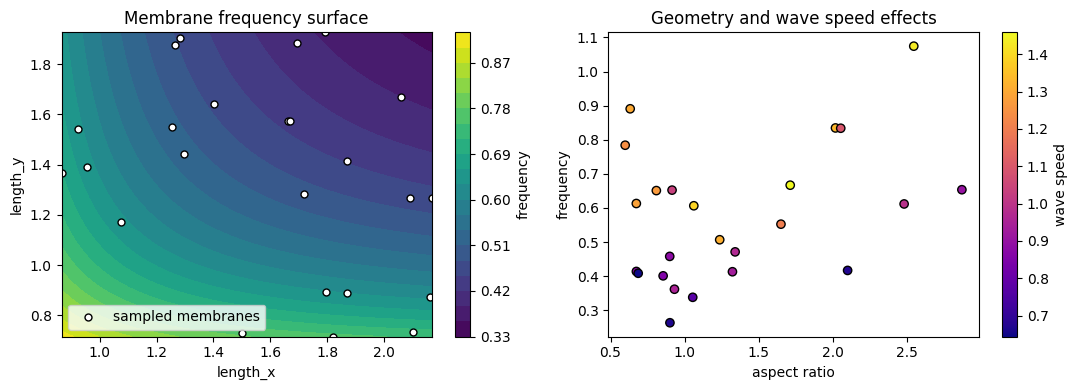

In [3]:
lx_grid = np.linspace(length_x.min(), length_x.max(), 80)
ly_grid = np.linspace(length_y.min(), length_y.max(), 80)
LX, LY = np.meshgrid(lx_grid, ly_grid)
F = membrane_frequency(LX, LY, np.median(wave_speed))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
contour = axes[0].contourf(LX, LY, F, levels=18, cmap="viridis")
axes[0].scatter(length_x, length_y, c="white", edgecolor="black", s=25, label="sampled membranes")
axes[0].set_title("Membrane frequency surface")
axes[0].set_xlabel("length_x")
axes[0].set_ylabel("length_y")
axes[0].legend()
fig.colorbar(contour, ax=axes[0], label="frequency")
scatter = axes[1].scatter(length_x / length_y, frequency, c=wave_speed, cmap="plasma", edgecolor="black")
axes[1].set_title("Geometry and wave speed effects")
axes[1].set_xlabel("aspect ratio")
axes[1].set_ylabel("frequency")
fig.colorbar(scatter, ax=axes[1], label="wave speed")
plt.tight_layout()
plt.show()


## Package-client surrogate models

In [4]:
qkr = QuantumKernelRegressor(QuantumKernel(embedding="iqp", seed=821), alpha=2e-3)
qkr.fit(x_train, y_train)
qkr_frequency = y_scaler.inverse_transform(qkr.predict(x_test).reshape(-1, 1)).ravel()

trainable_qkr = TrainableQuantumKernelRegressor(
    embedding_layers=1,
    alpha=5e-3,
    steps=1,
    step_size=0.05,
    seed=822,
)
trainable_qkr.fit(x_train, y_train)
trainable_frequency = y_scaler.inverse_transform(trainable_qkr.predict(x_test).reshape(-1, 1)).ravel()

ridge = Ridge(alpha=1e-2)
ridge.fit(x_train, y_train)
ridge_frequency = y_scaler.inverse_transform(ridge.predict(x_test).reshape(-1, 1)).ravel()

results = {
    "quantum_kernel_frequency_mae": mean_absolute_error(y_test_raw, qkr_frequency),
    "trainable_quantum_kernel_frequency_mae": mean_absolute_error(y_test_raw, trainable_frequency),
    "ridge_frequency_mae": mean_absolute_error(y_test_raw, ridge_frequency),
    "quantum_kernel_frequency_mse": mean_squared_error(y_test_raw, qkr_frequency),
}

print_section(
    "Results",
    [
        ("Quantum kernel frequency MAE", results["quantum_kernel_frequency_mae"]),
        ("Trainable quantum kernel frequency MAE", results["trainable_quantum_kernel_frequency_mae"]),
        ("Ridge frequency MAE", results["ridge_frequency_mae"]),
    ],
)


Results
+----------------------------------------+-----------+
| Metric                                 | Value     |
+----------------------------------------+-----------+
| Quantum kernel frequency MAE           | 0.0662286 |
| Trainable quantum kernel frequency MAE | 0.0524166 |
| Ridge frequency MAE                    | 0.033425  |
+----------------------------------------+-----------+



## Plots

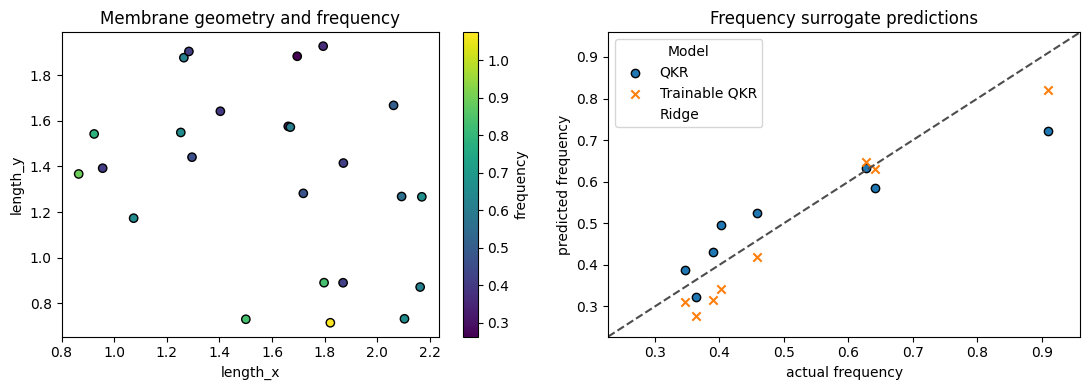

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
scatter = axes[0].scatter(length_x, length_y, c=frequency, cmap="viridis", edgecolor="black")
axes[0].set_title("Membrane geometry and frequency")
axes[0].set_xlabel("length_x")
axes[0].set_ylabel("length_y")
fig.colorbar(scatter, ax=axes[0], label="frequency")

low = min(y_test_raw.min(), qkr_frequency.min(), trainable_frequency.min(), ridge_frequency.min()) - 0.05
high = max(y_test_raw.max(), qkr_frequency.max(), trainable_frequency.max(), ridge_frequency.max()) + 0.05
axes[1].scatter(y_test_raw, qkr_frequency, label="QKR", edgecolor="black")
axes[1].scatter(y_test_raw, trainable_frequency, marker="x", label="Trainable QKR")
axes[1].scatter(y_test_raw, ridge_frequency, marker="s", facecolors="none", label="Ridge")
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Frequency surrogate predictions")
axes[1].set_xlabel("actual frequency")
axes[1].set_ylabel("predicted frequency")
axes[1].legend(title="Model")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "vibrating_membrane_eigenfrequency_surrogate",
        "n_train": int(len(y_train_raw)),
        "n_test": int(len(y_test_raw)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_frequency": float(a), "quantum_kernel_frequency": float(q), "trainable_frequency": float(t)}
        for a, q, t in zip(y_test_raw[:6], qkr_frequency[:6], trainable_frequency[:6])
    ],
    "passed": bool(
        np.isfinite(qkr_frequency).all()
        and np.isfinite(trainable_frequency).all()
        and results["quantum_kernel_frequency_mae"] < 0.35
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+---------------------------------------------+
| Metric        | Value                                       |
+---------------+---------------------------------------------+
| problem       | vibrating_membrane_eigenfrequency_surrogate |
| n_train       | 16                                          |
| n_test        | 8                                           |
| feature_count | 4                                           |
+---------------+---------------------------------------------+

Results
+----------------------------------------+------------+
| Metric                                 | Value      |
+----------------------------------------+------------+
| quantum_kernel_frequency_mae           | 0.0662286  |
| trainable_quantum_kernel_frequency_mae | 0.0524166  |
| ridge_frequency_mae                    | 0.033425   |
| quantum_kernel_frequency_mse           | 0.00699331 |
+----------------------------------------+------------+

Sample pred